<h1>Overview</h1>
This notebook focuses on predicting gold prices in INR using machine learning and time-series models. The workflow includes data collection, preprocessing, feature engineering, model training, evaluation, visualization, and deployment using Gradio. Below is an in-depth breakdown of its key components.

In [2]:
# Initializing all the Needed Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import gradio as gr

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.linear_model import Ridge

In [4]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

1.Data Collection & Preprocessing

Data Source

The dataset consists of 53 weekly data points from 2024, including Date, USD/INR exchange rate, and Gold Rate in INR.

Retrieved from Exchange Rates.

In [5]:
gold_usdinr = pd.read_csv('../Data/Gold vs USDINR.csv')

In [6]:
gold_usdinr.head(5)

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,"₹5,066.31"
1,2024-01-08,83.076103,"₹4,966.31"
2,2024-01-15,83.160599,"₹5,015.33"
3,2024-01-22,83.146103,"₹4,950.84"
4,2024-01-29,82.927597,"₹4,976.77"


In [7]:

gold_usdinr.describe()

,USD_INR
count,53.000000
mean,83.717398
std,0.637302
min,82.752296
25%,83.301804
50%,83.544998
75%,83.988998
max,85.786598


In [8]:
gold_usdinr["Goldrate"] = gold_usdinr["Goldrate"].replace("₹",'',regex=True).replace(',','',regex=True).astype(float)

In [9]:
gold_usdinr.head(5)

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,5066.31
1,2024-01-08,83.076103,4966.31
2,2024-01-15,83.160599,5015.33
3,2024-01-22,83.146103,4950.84
4,2024-01-29,82.927597,4976.77


<h1>2.Exploratory Data Analysis (EDA)</h1>

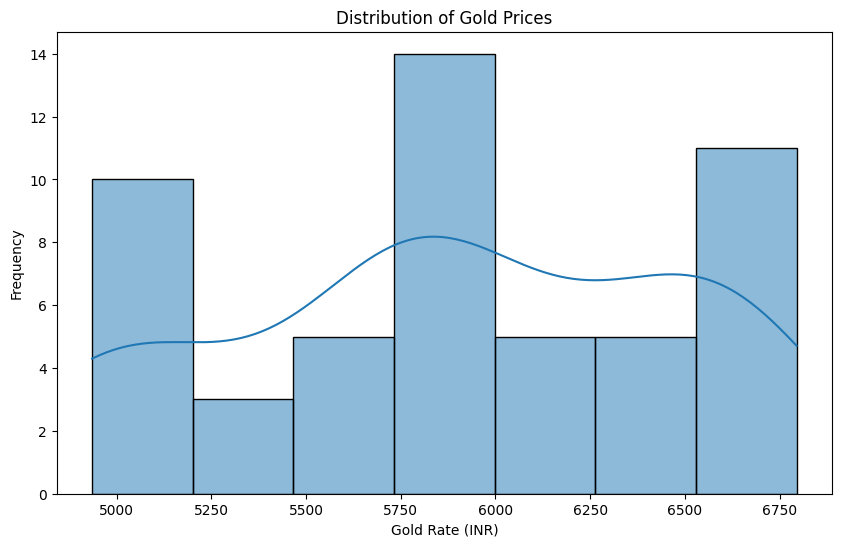

In [10]:
# Visualize the distribution of 'Goldrate'
plt.figure(figsize=(10, 6))
sns.histplot(gold_usdinr['Goldrate'], kde=True)
plt.title('Distribution of Gold Prices')
plt.xlabel('Gold Rate (INR)')
plt.ylabel('Frequency')
plt.show()

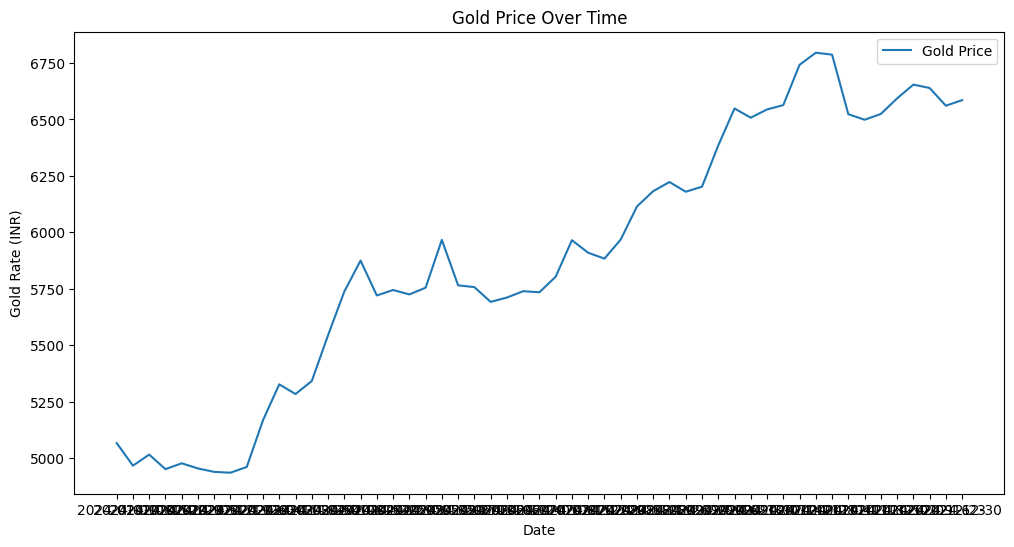

In [11]:

# Examine the relationship between gold prices and USDINR
plt.figure(figsize=(12,6))
sns.lineplot(data=gold_usdinr, x='Date', y='Goldrate', label='Gold Price')
plt.title('Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Gold Rate (INR)')
plt.show()

<Axes: ylabel='USD_INR'>

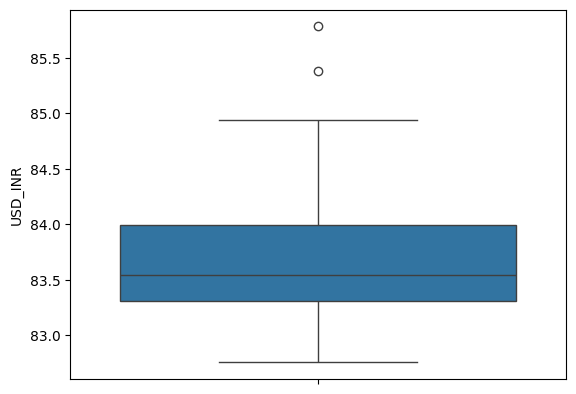

In [12]:

sns.boxplot(data=gold_usdinr['USD_INR'])

In [13]:
#Remove outliers

#Calculate IQR for USD_INR
Q1 = gold_usdinr['USD_INR'].quantile(0.25)
Q3 = gold_usdinr['USD_INR'].quantile(0.75)

# Define bounds for outliers

IQR = Q3-Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

# Remove outliers based on the bounds
gold_usdinr_cleaned = gold_usdinr[
    (gold_usdinr['USD_INR'] >=lower_bound) &
    (gold_usdinr['USD_INR'] <=upper_bound)
]


In [14]:
# Print the number of outliers removed
print(f"Number of outliers removed: {len(gold_usdinr) - len(gold_usdinr_cleaned)}")

Number of outliers removed: 2


<Axes: ylabel='USD_INR'>

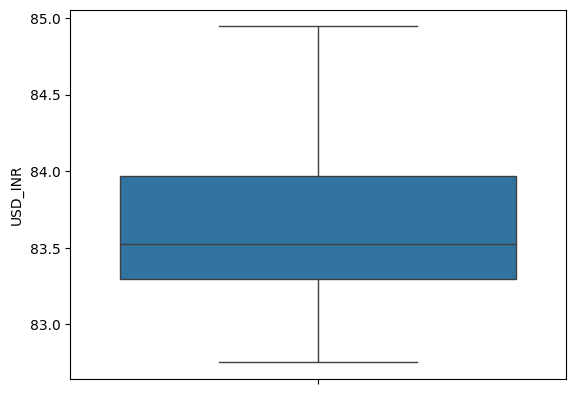

In [15]:
sns.boxplot(data=gold_usdinr_cleaned['USD_INR'])

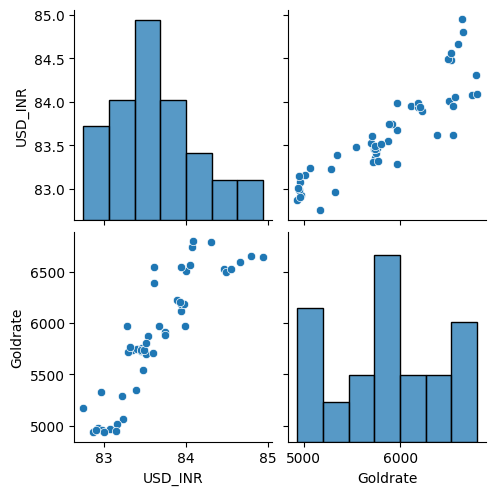

In [16]:
sns.pairplot(gold_usdinr_cleaned)

<Axes: xlabel='Goldrate', ylabel='USD_INR'>

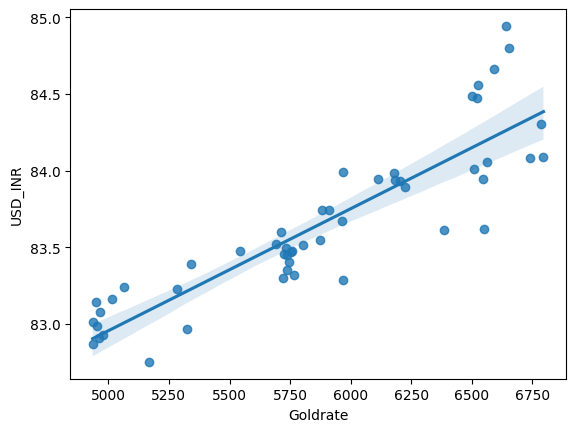

In [17]:
sns.regplot(x='Goldrate',y='USD_INR',data=gold_usdinr_cleaned)

<h1>3.Feature Engineering</h1>

* Extracted temporal features (e.g., day, month, year, day of the week) to capture seasonal trends.
* Standardized features before feeding them into machine learning models.
* Implemented feature selection to retain the most important attributes for prediction.

In [18]:
X = gold_usdinr_cleaned[['USD_INR']]
y = gold_usdinr_cleaned[['Goldrate']]

In [19]:
print(X.shape)
print(y.shape)

(51, 1)
(51, 1)


In [20]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40, 1)
(11, 1)
(40, 1)
(11, 1)


In [22]:
#standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
X_train_scaled

array([[-1.28057948e+00],
       [ 2.15516837e+00],
       [-1.10040558e+00],
       [ 1.71016575e+00],
       [-1.24934489e+00],
       [ 5.80053355e-01],
       [ 5.90584978e-01],
       [-2.63986902e-01],
       [ 1.90814640e+00],
       [-1.27948818e-01],
       [-1.56774633e+00],
       [-5.69667239e-01],
       [-2.21666410e-01],
       [ 1.25499179e+00],
       [-2.98865962e-01],
       [-7.06259609e-01],
       [-6.80831281e-01],
       [ 1.55905082e+00],
       [-1.76075567e-01],
       [ 5.07953312e-01],
       [-1.14454139e+00],
       [ 2.34228128e-01],
       [-1.34762630e-03],
       [-9.79610650e-01],
       [-5.34982180e-01],
       [-8.26139974e-01],
       [ 7.15550994e-01],
       [ 6.68685278e-01],
       [-1.69534864e-01],
       [ 7.96201058e-01],
       [-1.18032120e+00],
       [-2.58540948e-01],
       [-2.83428831e-01],
       [ 2.41489758e+00],
       [-5.97645330e-01],
       [-1.34978333e+00],
       [ 8.47057712e-01],
       [-4.83404938e-01],
       [ 1.0

In [24]:
X_train.head(5)

,USD_INR
8,82.910400
49,84.802002
6,83.009598
47,84.556999
4,82.927597


In [25]:
X_test_scaled

array([[ 0.86467046],
       [ 0.60039603],
       [ 1.58537988],
       [-0.40402977],
       [-0.02514078],
       [ 0.67849631],
       [-0.37986245],
       [ 0.60458095],
       [-0.85246901],
       [ 0.23331354],
       [-0.25000479]])

<h1>4. Model Training & Evaluation</h1>

<h2>Models Implemented</h2>

1. Linear Regression – Basic baseline model.

2. Random Forest Regressor – Applied hyperparameter tuning with RandomizedSearchCV.

3. ARIMA – Time-series forecasting model.

<h1>1. Linear Regression Model</h1>

In [26]:
lin_reg = LinearRegression()

In [27]:
lin_reg.fit(X_train_scaled,y_train)

LinearRegression()

LinearRegression()

In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.

On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [28]:
lin_reg.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [29]:
y_pred = lin_reg.predict(X_test_scaled)
print(y_pred)
print(y_test)

[[6303.91716248]
 [6165.06820038]
 [6682.57563976]
 [5637.34602291]
 [5836.4131137 ]
 [6206.10184462]
 [5650.04345372]
 [6167.26694494]
 [5401.73744228]
 [5972.20420554]
 [5718.27026614]]
    Goldrate
43   6795.35
40   6544.00
46   6498.43
12   5341.21
24   5710.88
31   5967.66
17   5744.34
32   6114.39
3    4950.84
30   5883.33
13   5543.85


In [30]:
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Squared Error: 75693.83147343161
Root Mean Squared Error: 275.1251196699996
R-squared: 0.7244658615036521


In [31]:
#parameter tuning using randomizedsearchcv
# Define the parameter grid for RandomizedSearchCV
param_grid = {
    'alpha': np.logspace(-4, 4, 50),  # Explore a wide range of alpha values
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],  # Different solvers
    'fit_intercept': [True, False]  # Include or exclude the intercept
}
# Create a Ridge regression model
ridge = Ridge()

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=ridge,
    param_distributions=param_grid,
    n_iter=10,  # Number of random parameter combinations to try
    cv=5,  # Number of cross-validation folds
    scoring='neg_mean_squared_error',  # Use negative MSE as the scoring metric
    n_jobs=-1,  # Use all available CPU cores
    random_state=42,  # Set a random state for reproducibility
    verbose=2  # Set verbosity for output
)

In [32]:
# Fit the RandomizedSearchCV object to your training data
random_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END alpha=0.0062505519252739694, fit_intercept=True, solver=sparse_cg; total time=   0.0s
[CV] END alpha=0.0062505519252739694, fit_intercept=True, solver=sparse_cg; total time=   0.0s
[CV] END alpha=51.79474679231202, fit_intercept=False, solver=lsqr; total time=   0.0s
[CV] END alpha=0.0062505519252739694, fit_intercept=True, solver=sparse_cg; total time=   0.0s
[CV] END alpha=0.0062505519252739694, fit_intercept=True, solver=sparse_cg; total time=   0.0s
[CV] END alpha=51.79474679231202, fit_intercept=False, solver=lsqr; total time=   0.0s
[CV] END alpha=0.0062505519252739694, fit_intercept=True, solver=sparse_cg; total time=   0.0s
[CV] END alpha=51.79474679231202, fit_intercept=False, solver=lsqr; total time=   0.0s
[CV] END alpha=3.727593720314938, fit_intercept=True, solver=sparse_cg; total time=   0.0s
[CV] END alpha=3.727593720314938, fit_intercept=True, solver=sparse_cg; total time=   0.0s
[CV] END alpha=3.7275

RandomizedSearchCV(cv=5, estimator=Ridge(), n_jobs=-1,
                   param_distributions={'alpha': array([1.00000000e-04, 1.45634848e-04, 2.12095089e-04, 3.08884360e-04,
       4.49843267e-04, 6.55128557e-04, 9.54095476e-04, 1.38949549e-03,
       2.02358965e-03, 2.94705170e-03, 4.29193426e-03, 6.25055193e-03,
       9.10298178e-03, 1.32571137e-02, 1.93069773e-02, 2.81176870e-02,
       4.09491506e-02, 5.96362...
       7.54312006e+01, 1.09854114e+02, 1.59985872e+02, 2.32995181e+02,
       3.39322177e+02, 4.94171336e+02, 7.19685673e+02, 1.04811313e+03,
       1.52641797e+03, 2.22299648e+03, 3.23745754e+03, 4.71486636e+03,
       6.86648845e+03, 1.00000000e+04]),
                                        'fit_intercept': [True, False],
                                        'solver': ['auto', 'svd', 'cholesky',
                                                   'lsqr', 'sparse_cg', 'sag',
                                                   'saga']},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [33]:
# Print the best hyperparameters found
print("Best hyperparameters:", random_search.best_params_)

Best hyperparameters: {'solver': 'saga', 'fit_intercept': True, 'alpha': 1.2067926406393288}


In [34]:
# Get the best model
best_ridge = random_search.best_estimator_
# Evaluate the best model on the test set
y_pred_best = best_ridge.predict(X_test_scaled)

In [35]:
# Calculate the metrics for the best model
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Best Model Mean Squared Error: {mse_best}")
print(f"Best Model Root Mean Squared Error: {rmse_best}")
print(f"Best Model R-squared: {r2_best}")

Best Model Mean Squared Error: 77671.90970824767
Best Model Root Mean Squared Error: 278.69680606036314
Best Model R-squared: 0.7172654321991887


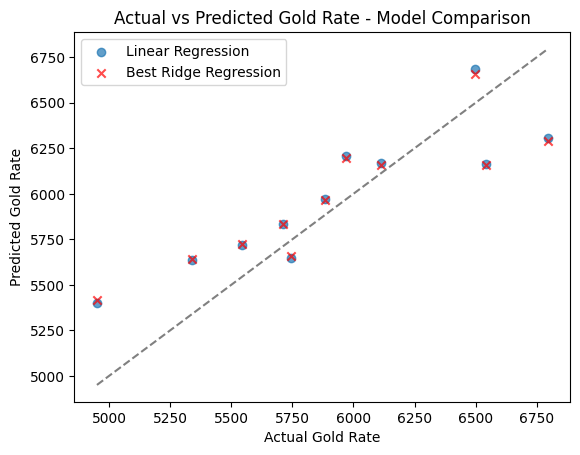

In [36]:

# comparing results of models through plots

import matplotlib.pyplot as plt

# Create a figure and an axes
fig, ax = plt.subplots()

# Plot the actual vs predicted values for the original linear regression model
ax.scatter(y_test, y_pred, label='Linear Regression', alpha=0.7)

# Plot the actual vs predicted values for the best Ridge regression model
ax.scatter(y_test, y_pred_best, label='Best Ridge Regression', alpha=0.7, marker='x', color='red')


# Add labels and title
ax.set_xlabel('Actual Gold Rate')
ax.set_ylabel('Predicted Gold Rate')
ax.set_title('Actual vs Predicted Gold Rate - Model Comparison')

# Add a legend
ax.legend()

# Add a diagonal line for reference
# Get the minimum and maximum values directly without indexing
min_value = min(y_test.min().values[0], y_pred.min(), y_pred_best.min())
max_value = max(y_test.max().values[0], y_pred.max(), y_pred_best.max())


ax.plot([min_value, max_value], [min_value, max_value], color='gray', linestyle='--')

# Show the plot
plt.show()

<h1>2. Random Forest Regressor</h1>

In [ ]:
#using random forest regressor
#initialize the RandomForestRegressor
rf_regressor =RandomForestRegressor(random_state=42)
#Define the parameter grid for RandomizedSearchCV (expanded for RandomForest)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

In [38]:
#Initialize RandomizedSearchCV for RandomForest

random_search_rf = RandomizedSearchCV(
    estimator=rf_regressor,
    param_distributions=param_grid_rf,
    n_iter=10, #number of random combinations to try,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2)

In [40]:
# Fit the RandomForest model with RandomizedSearchCV
random_search_rf.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/Users/hoangvulinh/miniforge3/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/hoangvulinh/miniforge3/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/hoangvulinh/miniforge3/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/hoangvulinh/miniforge3/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array

[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time=   0.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time=   0.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time=   0.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time=   0.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.0s
[CV] END max_depth=30, max_features=log2, mi

/Users/hoangvulinh/miniforge3/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/hoangvulinh/miniforge3/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/hoangvulinh/miniforge3/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/hoangvulinh/miniforge3/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [41]:
#print the best hyperparameters for RandomForest
print("Best hyperparameters for RandomForest:", random_search_rf.best_params_)

Best hyperparameters for RandomForest: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}


In [42]:
#Get the best RandomForest Model
best_rf = random_search_rf.best_estimator_
#Predict using the best RnadomForest Model
y_pred_rf = best_rf.predict(X_test_scaled)

In [43]:
# Evaluate the best RandomForest model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Mean Squared Error: {mse_rf}")
print(f"Random Forest - Root Mean Squared Error: {rmse_rf}")
print(f"Random Forest - R-squared: {r2_rf}")
     

Random Forest - Mean Squared Error: 81500.73831135004
Random Forest - Root Mean Squared Error: 285.4833415654056
Random Forest - R-squared: 0.703328061477292


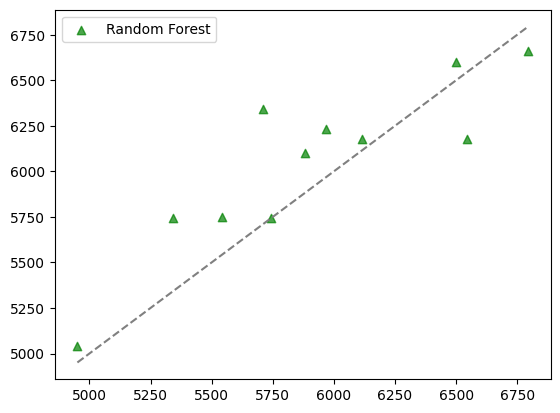

In [44]:
# ... (rest of your plotting code, modified to include Random Forest results)
fig, ax = plt.subplots()

# Plot for Random Forest
ax.scatter(y_test, y_pred_rf, label='Random Forest', alpha=0.7, marker='^', color='green')

# Update legend and limits (as before)
ax.legend()

min_value = min(y_test.min().values[0], y_pred.min(), y_pred_best.min(), y_pred_rf.min())
max_value = max(y_test.max().values[0], y_pred.max(), y_pred_best.max(), y_pred_rf.max())
ax.plot([min_value, max_value], [min_value, max_value], color='gray', linestyle='--')

plt.show()

<h1> 3. ARIMA model </h1>

In [45]:
#Mô hình dùng để dự báo dữ liệu chuỗi thời gian (time series)

In [46]:
#Use Arima model
#Prepare the data for Arima (using 'GoldRate' as the time series)
gold_prices = gold_usdinr_cleaned['Goldrate']

#Split data into training and testing sets
train_size = int(len(gold_prices)*0.8)
train,test = gold_prices[:train_size], gold_prices[train_size:]

In [51]:
#Fit the ARIMA model
# (p, d, q) are the order of the model. You might need to tune these parameters.
model = ARIMA(train, order=(5, 1, 0))  # Example order, adjust as needed
model_fit = model.fit()

In [52]:
#Make predictions
predictions = model_fit.predict(start=len(train), end=len(gold_prices)-1)

In [53]:
# Evaluate the model
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f'Test RMSE: {rmse}')
     

Test RMSE: 122.12108172927466


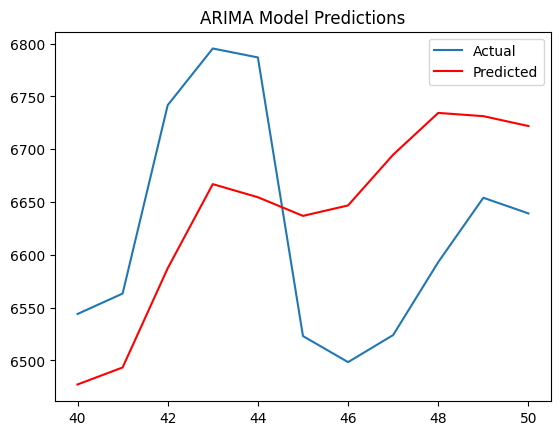

In [54]:
# Plot the results
plt.plot(test, label='Actual')
plt.plot(predictions, color='red', label='Predicted')
plt.legend()
plt.title('ARIMA Model Predictions')
plt.show()


<h1>5. Results and Evaluation</h1>

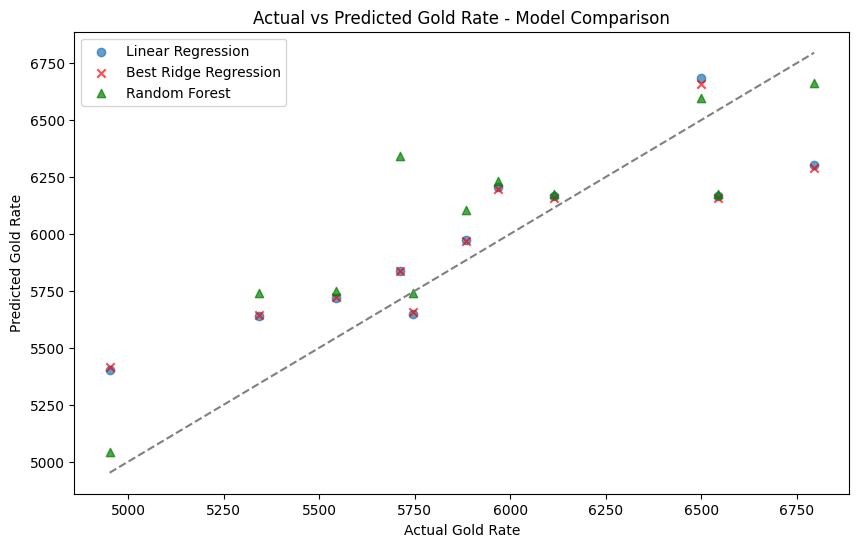

In [55]:
# compare linear and random forest regression models

# Create a figure and an axes for the comparison plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the actual vs predicted values for the original linear regression model
ax.scatter(y_test, y_pred, label='Linear Regression', alpha=0.7)

# Plot the actual vs predicted values for the best Ridge regression model
ax.scatter(y_test, y_pred_best, label='Best Ridge Regression', alpha=0.7, marker='x', color='red')

# Plot for Random Forest
ax.scatter(y_test, y_pred_rf, label='Random Forest', alpha=0.7, marker='^', color='green')

# Add labels, title, legend, and diagonal line (as before)
ax.set_xlabel('Actual Gold Rate')
ax.set_ylabel('Predicted Gold Rate')
ax.set_title('Actual vs Predicted Gold Rate - Model Comparison')
ax.legend()

min_value = min(y_test.min().values[0], y_pred.min(), y_pred_best.min(), y_pred_rf.min())
max_value = max(y_test.max().values[0], y_pred.max(), y_pred_best.max(), y_pred_rf.max())
ax.plot([min_value, max_value], [min_value, max_value], color='gray', linestyle='--')

plt.show()

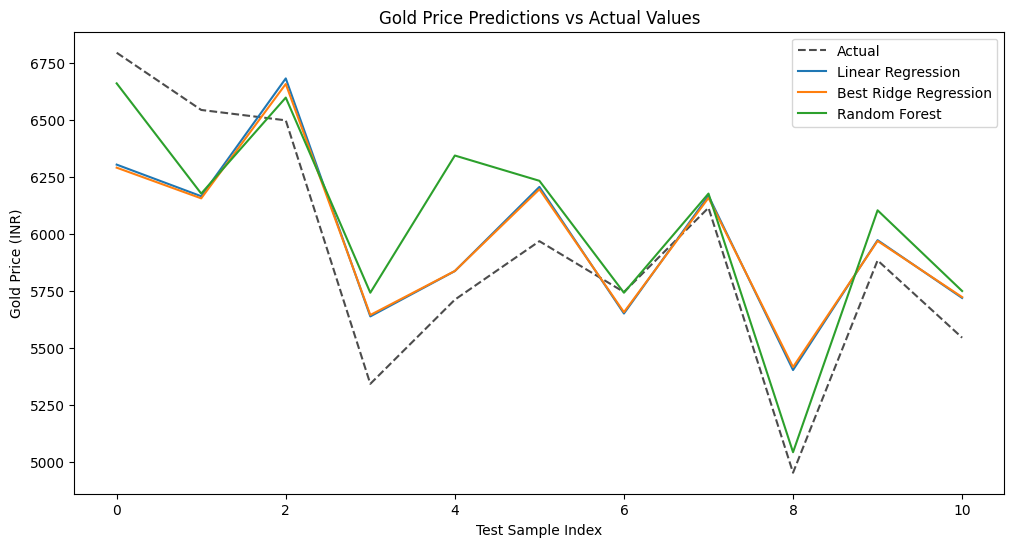

In [57]:
# Actual vs Predicted Data
y_test_values = range(len(y_test))  # X-axis (Sample Index)
y_actual = y_test.values

# Model Predictions
predictions = {
    "Linear Regression": y_pred,
    "Best Ridge Regression": y_pred_best,
    "Random Forest": y_pred_rf,
}

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test_values, y_actual, label="Actual", linestyle='dashed', color='black', alpha=0.7)

for model, y_pred in predictions.items():
    plt.plot(y_test_values, y_pred, label=model)

plt.legend()
plt.title("Gold Price Predictions vs Actual Values")
plt.xlabel("Test Sample Index")
plt.ylabel("Gold Price (INR)")
plt.show()

In [58]:
# Create a DataFrame for easy comparison of metrics
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Best Ridge Regression', 'Random Forest'],
    'MSE': [mse, mse_best, mse_rf],
    'RMSE': [rmse, rmse_best, rmse_rf],
    'R-squared': [r2, r2_best, r2_rf]
})

results_df

,Model,MSE,RMSE,R-squared
0,Linear Regression,75693.831473,122.121082,0.724466
1,Best Ridge Regression,77671.909708,278.696806,0.717265
2,Random Forest,81500.738311,285.483342,0.703328


<h1>Linear regression is the best model for this problem</h1>

<h1>6. Deployment Using Gradio </h1>

In [66]:
# save the models

joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(lin_reg, 'models/Regression_model.pkl')
joblib.dump(best_ridge, 'models/best_ridge_model.pkl')
joblib.dump(best_rf, 'models/best_random_forest_model.pkl')

print("Models saved successfully.")

Models saved successfully.


In [65]:
import os

os.makedirs("models", exist_ok=True)

In [67]:
#prompt: Create a function to calculate goldrate
def predict_gold_rate(usd_inr_value):
    """
    Predicts the gold rate based on the USD/INR exchange rate using a pre-trained model.

    Args:
        usd_inr_value (float): The USD/INR exchange rate.

    Returns:
        float: The predicted gold rate.
    """
    try:
        #Load the pre-trained scaler and model
        scaler = joblib.load('models/scaler.pkl')
        model = joblib.load('models/Regression_model.pkl') #Use the best model
        
        #Reshape the input for prediction
        usd_inr_scaled = scaler.transform(np.array([[usd_inr_value]]))
        #Make the prediction
        predicted_gold_rate = model.predict(usd_inr_scaled)
        
        return predicted_gold_rate[0][0] #Extract the predicted value
    except FileNotFoundError:
        return "Error: Model files not found. Please ensure 'scaler.pkl' and 'best_ridge_model.pkl' are in the same directory."
    except Exception as e:
        return f"An error occurred: {e}"

In [68]:
# prompt: use gradio for predict gold rate

iface = gr.Interface(
    fn=predict_gold_rate,
    inputs=gr.Number(label="USD/INR Exchange Rate"),
    outputs= gr.Number(label="output"),
    title="Gold Rate Prediction🥇",
    description="Enter the USD/INR exchange rate to predict the gold rate.",
)

iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://f623a07c8eb028bdf1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/Users/hoangvulinh/miniforge3/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
